# Arabic Sentiment Analysis

## Data Acquisition and Initial Setup

### Clone Repository

In [ ]:
import os

# Clone the repository
!git clone https://github.com/elnagara/HARD-Arabic-Dataset.git


Cloning into 'HARD-Arabic-Dataset'...
remote: Enumerating objects: 100, done.
remote: Total 100 (delta 0), reused 0 (delta 0), pack-reused 100 (from 1)
Receiving objects: 100% (100/100), 116.36 MiB | 25.58 MiB/s, done.
Resolving deltas: 100% (35/35), done.


### Install Libraries

In [ ]:
import matplotlib.pyplot as plt
import re
import html
import pandas as pd

### Explore Repository Structure

In [ ]:
# Change directory to the cloned repository
repo_path = 'HARD-Arabic-Dataset'
os.chdir(repo_path)

print(f"Listing all files in '{repo_path}':\n")

# Walk through the directory and print all file paths
for dirpath, dirnames, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirpath, filename))

Listing all files in 'HARD-Arabic-Dataset':

./datasets.png
./README.md
./data/balanced-reviews.zip
./data/readme.txt
./data/unbalanced-reviews.rar
./.git/packed-refs
./.git/config
./.git/index
./.git/description
./.git/HEAD
./.git/logs/HEAD
./.git/logs/refs/remotes/origin/HEAD
./.git/logs/refs/heads/master
./.git/refs/remotes/origin/HEAD
./.git/refs/heads/master
./.git/info/exclude
./.git/objects/pack/pack-001e9379a293495b0cf9b4b5ea4ec556f68f2609.pack
./.git/objects/pack/pack-001e9379a293495b0cf9b4b5ea4ec556f68f2609.idx
./.git/hooks/pre-merge-commit.sample
./.git/hooks/fsmonitor-watchman.sample
./.git/hooks/commit-msg.sample
./.git/hooks/pre-rebase.sample
./.git/hooks/pre-receive.sample
./.git/hooks/pre-applypatch.sample
./.git/hooks/update.sample
./.git/hooks/pre-push.sample
./.git/hooks/post-update.sample
./.git/hooks/pre-commit.sample
./.git/hooks/push-to-checkout.sample
./.git/hooks/applypatch-msg.sample
./.git/hooks/prepare-commit-msg.sample


## Data Loading and Preprocessing

### Unzip Dataset

In [ ]:
import zipfile
import pandas as pd
import os

zip_file_path = './data/balanced-reviews.zip'
extract_dir = './data/balanced-reviews_extracted'

# Create a directory to extract the contents into if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'.")

# List the contents of the extracted directory to find the dataset file
print('\nContents of extracted directory:')
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))


'./data/balanced-reviews.zip' unzipped to './data/balanced-reviews_extracted'.

Contents of extracted directory:
./data/balanced-reviews_extracted/balanced-reviews.txt


### Load Data

In [ ]:
dataset_file_name = 'balanced-reviews.txt' # Corrected file name
dataset_path = os.path.join(extract_dir, dataset_file_name)

# Read the first few lines of the file to inspect its format
try:
    # Read with utf-16 encoding to handle the BOM and interleaved null characters
    with open(dataset_path, 'r', encoding='utf-16') as f:
        for i, line in enumerate(f):
            print(f"Line {i+1}: {line.strip()}")
            if i >= 4: # Print first 5 lines
                break

    print("\nInspection complete. Now, attempting to load with pandas, specifying the correct encoding and delimiter.")
    # Attempt to load the dataset into a pandas DataFrame with utf-16 encoding and tab separator
    df = pd.read_csv(dataset_path, encoding='utf-16', sep='\t') # Changed encoding to utf-16
    print(f"\nSuccessfully loaded '{dataset_file_name}' into a DataFrame.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: '{dataset_file_name}' not found in '{extract_dir}'. Please check the extracted file names.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Line 1: no	Hotel name	rating	user type	room type	nights	review
Line 2: 2	فندق 72	2	مسافر منفرد	غرفة ديلوكس مزدوجة أو توأم	أقمت ليلة واحدة	“ممتاز”. النظافة والطاقم متعاون.
Line 3: 3	فندق 72	5	زوج	غرفة ديلوكس مزدوجة أو توأم	أقمت ليلة واحدة	استثنائي. سهولة إنهاء المعاملة في الاستقبال. لاشيئ
Line 4: 16	فندق 72	5	زوج	-	أقمت ليلتين	استثنائي. انصح بأختيار الاسويت و بالاخص غرفه رقم 801. نوعية الارضيه
Line 5: 20	فندق 72	1	زوج	غرفة قياسية مزدوجة	أقمت ليلة واحدة	“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق 2 نجمه

Inspection complete. Now, attempting to load with pandas, specifying the correct encoding and delimiter.

Successfully loaded 'balanced-reviews.txt' into a DataFrame.


,no,Hotel name,rating,user type,room type,nights,review
0,2,فندق 72,2,مسافر منفرد,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,“ممتاز”. النظافة والطاقم متعاون.
1,3,فندق 72,5,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...
2,16,فندق 72,5,زوج,-,أقمت ليلتين,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...
3,20,فندق 72,1,زوج,غرفة قياسية مزدوجة,أقمت ليلة واحدة,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...
4,23,فندق 72,4,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلتين,جيد. المكان جميل وهاديء. كل شي جيد ونظيف بس كا...


### Initial Data Inspection

In [ ]:
df.head()

,no,Hotel name,rating,user type,room type,nights,review
0,2,فندق 72,2,مسافر منفرد,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,“ممتاز”. النظافة والطاقم متعاون.
1,3,فندق 72,5,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...
2,16,فندق 72,5,زوج,-,أقمت ليلتين,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...
3,20,فندق 72,1,زوج,غرفة قياسية مزدوجة,أقمت ليلة واحدة,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...
4,23,فندق 72,4,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلتين,جيد. المكان جميل وهاديء. كل شي جيد ونظيف بس كا...


## Exploratory Data Analysis (EDA)

### Sentiment Distribution

In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (105698, 7)


In [ ]:
df.isna().sum()

,0
no,0
Hotel name,0
rating,0
user type,0
room type,0
nights,0
review,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['no', 'Hotel name', 'rating', 'user type', 'room type', 'nights',
       'review'],
      dtype='object')

In [ ]:
df.drop(columns=['no', 'Hotel name', 'user type', 'room type', 'nights'], axis=1, inplace=True)

In [ ]:
print("\nDuplicate rows:")
print(df.duplicated().sum())


Duplicate rows:
1619


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.columns

Index(['rating', 'review'], dtype='object')

In [ ]:
df.sample(5)

,rating,review
77538,2,ضعيف. أدوات المطبخ كانت شبه كامله. لا يوجد شبك...
100963,1,ضعيف جداً. الخدمات المجاوره فقط. كل شي ، لايوج...
14719,5,استثنائي. الديكور اكثر من رائع يجنن والمكان مر...
80460,5,استثنائي. جميع الخدمات رائعة.
31250,4,جيد. كل شي كان جيد الا الطعام. كان الطعام لم ي...


In [ ]:
print("\nData types:")
print(df.dtypes)


Data types:
rating     int64
review    object
dtype: object


In [ ]:
df['rating'].value_counts()

,count
rating,
2,38129
4,26217
5,25662
1,14071


### Review Length Analysis

In [ ]:
import numpy as np

# Define the conditions and choices for mapping ratings to sentiment
conditions = [
    df['rating'].isin([4, 5]), # Positive ratings
    df['rating'].isin([1, 2])  # Negative ratings
]
choices = ['positive', 'negative']

# Create the new 'sentiment' column
df['sentiment'] = np.select(conditions, choices, default='neutral')

# Display the value counts of the new sentiment column
print("Value counts for the new 'sentiment' column:")
print(df['sentiment'].value_counts())

# Display a sample of the DataFrame with the new sentiment column
print("\nSample of the DataFrame with 'sentiment' column:")
display(df.sample(5))


Value counts for the new 'sentiment' column:
sentiment
negative    52200
positive    51879
Name: count, dtype: int64

Sample of the DataFrame with 'sentiment' column:


,rating,review,sentiment
68960,2,“لن تتكرر !!!”. لا شئ يستحق الذكر. كذبة سيارة ...,negative
67589,4,“اقامه رائعه”. . كثره الناموس و الحشرات,positive
96347,4,“الفندق قريب جدا من المسجد النبوي”. قرب الفندق...,positive
91721,4,“انترنت سريعة وافطار رائع”. الإفطار رائع و متن...,positive
59964,2,“فاشل وأخر مره يتم الحجر فيه”. وسيلة النقل من ...,negative


In [ ]:
samples = df.sample(10, random_state=42)

for _, row in samples.iterrows():
    print(f"Rating: {row['rating']}")
    print(f"Review: {row['review']}")
    print(f"Sentiment: {row['sentiment']}")
    print("-" * 80)

Rating: 4
Review: “جيد”. قربه من القصباء. كل شيئ جميل
Sentiment: positive
--------------------------------------------------------------------------------
Rating: 2
Review: ضعيف. . وجود حيوان البريعص في الغرفة
Sentiment: negative
--------------------------------------------------------------------------------
Rating: 4
Review: “رحلة عمل وراحة”. كل الشكر والتقدير للمدير العام السيد رضا مختار على حسن رعايته ورقي تعامله 👍🌹وكذلك الطاقم المميز له وهم السكرتيرة الراقية تانيا ومستر بالا شكراً لكم من القلب 🌹🌹🌹. التأخير بإستلام الجناح الخاص بنا لكن بفضل حسن ادارة السيد رضا مختار تم عمل اللازم
Sentiment: positive
--------------------------------------------------------------------------------
Rating: 5
Review: “ممتاز”. مريح موقع ممتاز نظافه عامه الاستقبال متميزين. لا يوجد غلايات ماء ارجو توفيرها لدي طفل صغير احتجت ماء حار له و ما حصلت اضطريت اكلم الاستقبال يعطوني كاء حار فقط
Sentiment: positive
--------------------------------------------------------------------------------
Rating: 2
Review: ضعي

In [ ]:
print("\nStatistical summary:")
print(df.describe(include='object'))


Statistical summary:
                        review sentiment
count                   104079    104079
unique                  104036         2
top     “ممتاز”. كل شي ممتاز.   negative
freq                         3     52200


In [ ]:
sentiment_counts = df['sentiment'].value_counts()
sentiment_percent = df['sentiment'].value_counts(normalize=True) * 100

print(sentiment_counts)
print(sentiment_percent.round(2))

sentiment
negative    52200
positive    51879
Name: count, dtype: int64
sentiment
negative    50.15
positive    49.85
Name: proportion, dtype: float64


In [ ]:
print(df['rating'].value_counts().sort_index())

rating
1    14071
2    38129
4    26217
5    25662
Name: count, dtype: int64


In [ ]:
rating_counts = df['rating'].value_counts().sort_index()
rating_percent = df['rating'].value_counts(normalize=True).sort_index() * 100

print(rating_percent.round(2))

rating
1    13.52
2    36.63
4    25.19
5    24.66
Name: proportion, dtype: float64


In [ ]:
rating_sentiment = pd.crosstab(
    df['rating'],
    df['sentiment']
)

print(rating_sentiment)

sentiment  negative  positive
rating                       
1             14071         0
2             38129         0
4                 0     26217
5                 0     25662


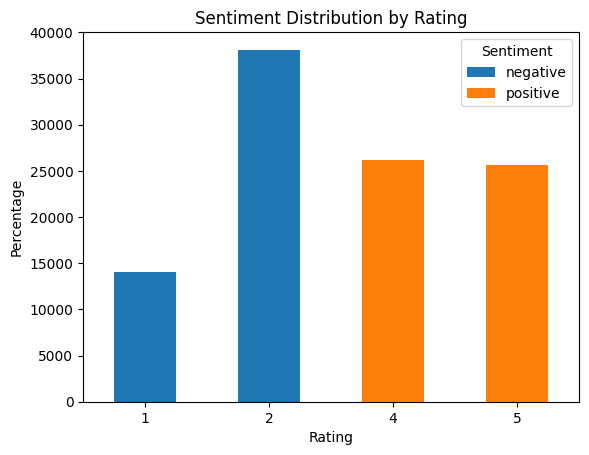

In [ ]:
rating_sentiment.plot(kind='bar', stacked=True)

plt.title('Sentiment Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Percentage')
plt.legend(title='Sentiment')
plt.xticks(rotation=0)
plt.show()

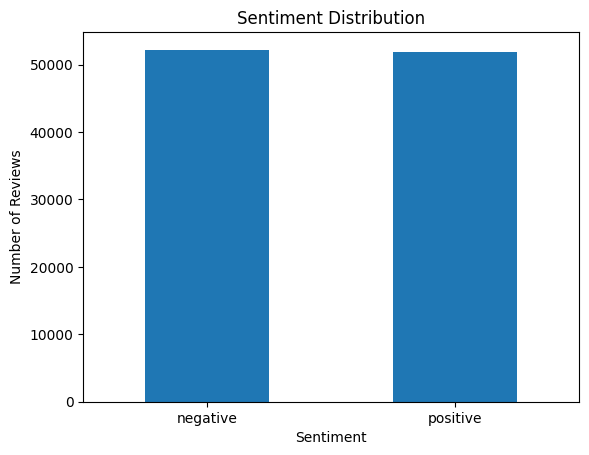

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

In [ ]:
df['review_length'] = df['review'].str.len()

### Text Quality and Noise Analysis

In [ ]:
print(df['review_length'].describe())

count    104079.000000
mean        138.813046
std         137.648980
min           5.000000
25%          55.000000
50%          97.000000
75%         173.000000
max        3365.000000
Name: review_length, dtype: float64


In [ ]:
df['word_count'] = df['review'].str.split().str.len()

print(df['word_count'].describe())

count    104079.000000
mean         24.249685
std          24.695879
min           2.000000
25%           9.000000
50%          17.000000
75%          30.000000
max         614.000000
Name: word_count, dtype: float64


In [ ]:
df['char_count_no_spaces'] = (
    df['review']
    .str.replace(r'\s+', '', regex=True)
    .str.len()
)

print(df['char_count_no_spaces'].describe())

count    104079.000000
mean        115.292778
std         112.985480
min           3.000000
25%          47.000000
50%          82.000000
75%         144.000000
max        2752.000000
Name: char_count_no_spaces, dtype: float64


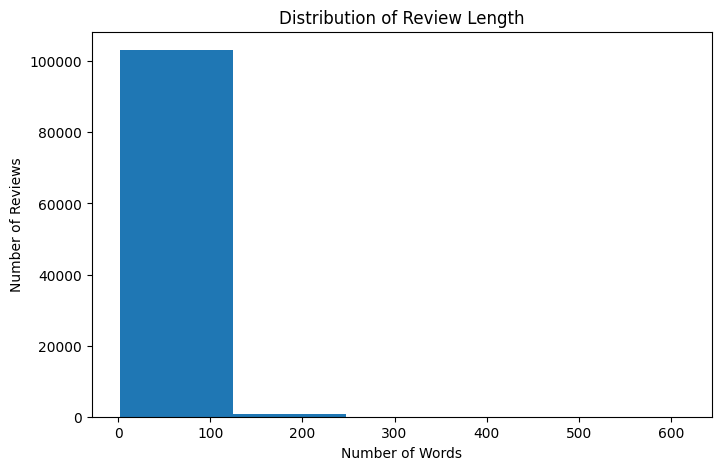

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['word_count'], bins=5)

plt.title('Distribution of Review Length')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
df.groupby('sentiment')['word_count'].mean()

,word_count
sentiment,
negative,28.357203
positive,20.116752


In [ ]:
df.groupby('sentiment')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,52200.0,28.357203,28.413528,2.0,11.0,20.0,35.0,614.0
positive,51879.0,20.116752,19.421032,2.0,8.0,14.0,25.0,570.0


In [ ]:
# Shortest reviews
print(
    df.nsmallest(10, 'word_count')
    [['rating', 'review', 'sentiment', 'word_count']]
)

      rating                                    review sentiment  word_count
119        5                        استثنائي. احترام.   positive           2
125        5                            “ممتاز”. نعم.   positive           2
355        5                           “ممتاز”. رائع.   positive           2
387        5  “ممتاز”. الهدوءالموقعالخدمةالسعرالراحة.   positive           2
1492       4                            رائع. المكان.   positive           2
1816       4                                جيد. نعم.   positive           2
2060       5                         استثنائي. ممتاز.   positive           2
2432       4                              جيد. شكراً.   positive           2
3037       2                              ضعيف. رائع.   negative           2
3178       5                        استثنائي. الموقع.   positive           2


In [ ]:
# Longest reviews
print(
    df.nlargest(10, 'word_count')
    [['rating', 'review', 'sentiment', 'word_count']]
)

       rating                                             review sentiment  \
20778       1  “فندق وادارة لايهمه الزبون وفريق متعالي على لا...  negative   
78562       5  “منتجع ممتاز للإستجمام”. لدي الكثير لأكتبه عن ...  positive   
53679       5  استثنائي. الفندق جدا جمييل للغايه ولكن هناك مل...  positive   
82383       4  “بشكل عام”. بالنسبه لموقعه عن المترو مو بعيد م...  positive   
90523       2  “نعم ولكن”. تم زيارة عائلتي لهذا الفندق أربع م...  negative   
21611       5  استثنائي. اولا الفندق اول واحد انا سكنت فيه لا...  positive   
39912       2  “اقامه لن تتكرر  -ـ- انترنت ضعيف ، سوء تعامل ،...  negative   
53670       2  “The beach and lifegurds are the only good thi...  negative   
51739       1  “الفندق يعاد ترميمه من جديد جميع الأدوار وليس ...  negative   
69142       2  مخيب للأمل. أخلاق مدير الفندق ورغبته في تطوير ...  negative   

       word_count  
20778         614  
78562         570  
53679         553  
82383         523  
90523         481  
21611         429  
3

In [ ]:
# Most common words
from collections import Counter
import re

text = ' '.join(df['review'].astype(str))

words = re.findall(r'[\u0600-\u06FF]+', text)

word_counts = Counter(words)

print(word_counts.most_common(20))

[('من', 51127), ('في', 48629), ('الفندق', 39246), ('جدا', 31358), ('لا', 30634), ('و', 22265), ('غير', 19147), ('جيد', 18468), ('جداً', 16860), ('الاستقبال', 16718), ('شي', 16501), ('كل', 16482), ('على', 15821), ('الغرف', 15487), ('ممتاز', 14785), ('ضعيف', 14292), ('فندق', 14259), ('لم', 13890), ('الموقع', 13609), ('يوجد', 12513)]


### Most Common Words by Sentiment

In [ ]:
# Positive reviews
positive_text = ' '.join(
    df[df['sentiment'] == 'positive']['review'].astype(str)
)

positive_words = re.findall(r'[\u0600-\u06FF]+', positive_text)

positive_counts = Counter(positive_words)

print(positive_counts.most_common(20))

[('من', 23010), ('في', 20307), ('الفندق', 17579), ('جيد', 14903), ('ممتاز', 13310), ('جدا', 12538), ('و', 10401), ('كل', 9897), ('رائع', 9075), ('لا', 8903), ('شي', 8115), ('الاستقبال', 7240), ('على', 6781), ('استثنائي', 6752), ('جداً', 6630), ('الموقع', 6545), ('فندق', 6410), ('جميل', 6168), ('الغرف', 5888), ('،', 4751)]


In [ ]:
# Negative reviews
negative_text = ' '.join(
    df[df['sentiment'] == 'negative']['review'].astype(str)
)

negative_words = re.findall(r'[\u0600-\u06FF]+', negative_text)

negative_counts = Counter(negative_words)

print(negative_counts.most_common(20))

[('في', 28322), ('من', 28117), ('لا', 21731), ('الفندق', 21667), ('جدا', 18820), ('غير', 15180), ('ضعيف', 13250), ('و', 11864), ('جداً', 10230), ('لم', 10054), ('الغرف', 9599), ('مخيب', 9574), ('الاستقبال', 9478), ('للأمل', 9379), ('على', 9040), ('شي', 8386), ('يوجد', 8059), ('فندق', 7849), ('ولا', 7782), ('الموقع', 7064)]


### Check for Very Short Reviews

In [ ]:
print(df[df['word_count'] <= 2][
    ['rating', 'review', 'sentiment', 'word_count']
].head(20))

      rating                                    review sentiment  word_count
119        5                        استثنائي. احترام.   positive           2
125        5                            “ممتاز”. نعم.   positive           2
355        5                           “ممتاز”. رائع.   positive           2
387        5  “ممتاز”. الهدوءالموقعالخدمةالسعرالراحة.   positive           2
1492       4                            رائع. المكان.   positive           2
1816       4                                جيد. نعم.   positive           2
2060       5                         استثنائي. ممتاز.   positive           2
2432       4                              جيد. شكراً.   positive           2
3037       2                              ضعيف. رائع.   negative           2
3178       5                        استثنائي. الموقع.   positive           2
3203       5                            “رائع”. رائع.   positive           2
3307       5                          استثنائي. يجنن.   positive           2

In [ ]:
print(
    (df['word_count'] <= 2).sum()
)

263


In [ ]:
print(
    (df['word_count'] <= 2).mean() * 100
)

0.25269266614783004


### Check Arabic Text Quality

In [ ]:
# English characters
english_count = df['review'].str.contains(
    r'[A-Za-z]',
    regex=True
).sum()

print("Reviews containing English characters:", english_count)

Reviews containing English characters: 2708


In [ ]:
# Numbers
numbers_count = df['review'].str.contains(
    r'\d',
    regex=True
).sum()

print("Reviews containing numbers:", numbers_count)

Reviews containing numbers: 13461


In [ ]:
# URLs
url_count = df['review'].str.contains(
    r'http[s]?://|www\.',
    regex=True
).sum()

print("Reviews containing URLs:", url_count)

Reviews containing URLs: 2


In [ ]:
# Arabic vs non-Arabic characters

arabic_count = df['review'].str.contains(
    r'[\u0600-\u06FF]',
    regex=True
).sum()

print("Reviews containing Arabic characters:", arabic_count)
print("Percentage:", round(arabic_count / len(df) * 100, 2), "%")

Reviews containing Arabic characters: 104013
Percentage: 99.94 %


In [ ]:
no_arabic = df[
    ~df['review'].str.contains(r'[\u0600-\u06FF]', regex=True)
]

print("Reviews without Arabic characters:", len(no_arabic))

print(
    no_arabic[['rating', 'review', 'sentiment']]
    .head(60)
)

Reviews without Arabic characters: 66
       rating                                             review sentiment
567         2  “Never again”. The price was reasonable for st...  negative
1012        5  “We had awonderful weekend in Ajman Saray”. Ev...  positive
1020        5  “Elegant &amp; quite place”. I liked everythin...  positive
1652        2                                        “4 😑”. . 4😑  negative
2951        4  “excellent”. Pleasant staff.good location.spac...  positive
3533        2                                   “Nice resort. .   negative
7314        2                       “??”. . No internet in rooms  negative
7835        5                                   “...”. .... ....  positive
8373        4  “it was a relaxing”. room size &amp; the view....  positive
8825        2                 “....”. ............ .............  negative
10608       5                                     “Good”. Pool.   positive
15279       2     “Location”. Location. Service and housekeepi

In [ ]:
# Analyze English characters
english_reviews = df[
    df['review'].str.contains(r'[A-Za-z]', regex=True)
]

print(
    english_reviews[['rating', 'review', 'sentiment']]
    .head(20)
)

     rating                                             review sentiment
39        5  “Superb”. الغرف وااااااسعهالموقع ممتاز مطل على...  positive
197       5             “mohamed”. فندق رائع جدا جدا. Nothaing  positive
283       1  ضعيف جداً. Nothingلا شي. الفندق سئ من جميع الن...  negative
294       4  “فندق هاديء جدا”. الشيء المميز في هذا الفندق ا...  positive
367       4  “قربه من القرية العالمية”. قرب الفندق من القري...  positive
381       4  “تجربه جديده”. وسع الغرفه ،مطبخ متكامل ،بلكونه...  positive
414       2  “فندق مزعج جدا جدا جدا”. nothing. ازعاااااااج ...  negative
428       2  “فندق الصراصير و الإزعاج....cockroach and nois...  negative
449       1  “Bad”. أسوء إقامة فندقية في حياتي... لم يعجبني...  negative
505       2  “So bad”. . روائح كريهه جداااا.. الارضيات وسخه...  negative
521       1  “تجربتي الفاشله في اختيار فندق اكاسيا”. لم يعج...  negative
567       2  “Never again”. The price was reasonable for st...  negative
575       4     “Good”. . الحوض صغير ولا يوجد مكان 

In [ ]:
english_percentage = len(english_reviews) / len(df) * 100

print(f"Percentage: {english_percentage:.2f}%")

Percentage: 2.60%


In [ ]:
# Analyze numbers
number_reviews = df[
    df['review'].str.contains(r'\d', regex=True)
]

print(
    number_reviews[['rating', 'review', 'sentiment']]
    .head(20)
)

     rating                                             review sentiment
2         5  استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...  positive
3         1  “استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...  negative
10        5  “إقامتي في فندق 72 الشارقة”. موقع الفندق ممتاز...  positive
23        4  جيد جداً. غرفه النوم والنظافة بشكل عام وتصميم ...  positive
27        2  مخيب للأمل. اكثر الفنادق تقدر تسوي جك أوت السا...  negative
32        2  “اقامة غير سعيدة لوجود قصور فالخدمة”. . مدخل ا...  negative
36        5  “فندق 72 وبس”. الموقع انه يطل على المنتزة والم...  positive
37        5  استثنائي. النظافةوهدوء المكان أسلوب تعامل المو...  positive
38        4  “الفندق مستواه لايستحق أكثر من ٤ نجوم”. الموقع...  positive
39        5  “Superb”. الغرف وااااااسعهالموقع ممتاز مطل على...  positive
55        4  “جميل”. الموقع. الانترنت لابد من تبديله كل يوم...  positive
59        4  جيد. موقع الفندق نظافه الفندق. منت حاجز سويت م...  positive
61        4  رائع. مميز جدا وانصح بهنظافه وخدمه يصل

Analyze URLs

In [ ]:
url_reviews = df[
    df['review'].str.contains(
        r'http[s]?://|www\.',
        regex=True
    )
]

print(
    url_reviews[['rating', 'review', 'sentiment']]
)

       rating                                             review sentiment
12066       1  ضعيف جداً. . عدم حقيقه الاسعار على الانترنت . ...  negative
35202       1  “لا انصح فيه”. اعجبني تواجد الصراصير منظر غير ...  negative


In [ ]:
# Analyze punctuation
punctuation_count = df['review'].str.contains(
    r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~،؛؟]',
    regex=True
).sum()

print("Reviews containing punctuation:", punctuation_count)

Reviews containing punctuation: 104079


In [ ]:
from collections import Counter

punctuation = []

for text in df['review'].astype(str):
    punctuation.extend(
        re.findall(r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~،؛؟]', text)
    )

punctuation_counts = Counter(punctuation)

print(punctuation_counts.most_common(20))

[('.', 282913), ('،', 22468), ('-', 12801), ('!', 8401), (')', 4133), ('(', 3938), (',', 3333), ('/', 2247), ('؟', 1929), ('+', 1551), (':', 1479), ('*', 1328), ('"', 807), ('_', 486), ('؛', 290), ('%', 263), (';', 244), ('&', 236), ('?', 224), ("'", 219)]


In [ ]:
# Analyze repeated characters
repeated_char_reviews = df[
    df['review'].str.contains(
        r'(.)\1{2,}',
        regex=True
    )
]

print(
    "Reviews with repeated characters:",
    len(repeated_char_reviews)
)

print(
    repeated_char_reviews[['review', 'sentiment']]
    .head(20)
)

/tmp/ipykernel_1013/3954951702.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['review'].str.contains(


Reviews with repeated characters: 8978
                                                review sentiment
9    استثنائي. المكان روعه تحديدا الغرف المطله على ...  positive
23   جيد جداً. غرفه النوم والنظافة بشكل عام وتصميم ...  positive
39   “Superb”. الغرف وااااااسعهالموقع ممتاز مطل على...  positive
40   استثنائي. النظافه وتعامل الطاقم العمل بصراحه ا...  positive
47                        “فندق من الاخر ...”. ممتاز.   positive
59   جيد. موقع الفندق نظافه الفندق. منت حاجز سويت م...  positive
78   استثنائي. الفندق رااااائع وسأكرر الزياره باذن ...  positive
85   “ضعيف”. لا شيا. سياء من حيث الغرف والمواقف وال...  negative
92   رائع. طاقم العمل لبق التعامل ..... حجم المسبح ...  positive
99   ممتاز. كل شي في الفندق أعجبني.الديكور الانارة،...  positive
101  “لا انصح فيه”. الافطار كان جيد. غااالي ومايستا...  negative
104  “فندق متميز ومن الطراز الأول”. أفضل خيار للسكن...  positive
117  “روووووعة”. جدا اكثر من الرائع وتصميم الديكور ...  positive
129  ممتاز. الفندق نظيف وديكوره عصري ويوجد كرسي يتح

In [ ]:
# Analyze Arabic letter variations
arabic_variants = {
    'أ': 'ا',
    'إ': 'ا',
    'آ': 'ا',
    'ى': 'ي',
}

for char in arabic_variants:
    count = df['review'].str.count(char).sum()
    print(f"{char}: {count}")

أ: 73243
إ: 20963
آ: 3419
ى: 55286


In [ ]:
# Check diacritics
diacritics_pattern = r'[\u064B-\u065F\u0670]'

diacritics_count = df['review'].str.contains(
    diacritics_pattern,
    regex=True
).sum()

print("Reviews containing Arabic diacritics:", diacritics_count)

Reviews containing Arabic diacritics: 18898


In [ ]:
# Check emojis
emoji_pattern = r'[\U0001F300-\U0001FAFF]'

emoji_count = df['review'].str.contains(
    emoji_pattern,
    regex=True
).sum()

print("Reviews containing emojis:", emoji_count)

Reviews containing emojis: 604


In [ ]:
emoji_reviews = df[
    df['review'].str.contains(
        emoji_pattern,
        regex=True
    )
]

print(
    emoji_reviews[['review', 'sentiment']]
    .head(20)
)

                                                 review sentiment
474   “لم يعجبني اطلاقاً”. سعر الفدق فقط. لايوجد افط...  negative
797   “لن اكرر الزيارة لهذا الفنقدق مرة أخرى😑”. . كا...  negative
866                  ضعيف. . صراصير و حشرات 😤في كل مكان  negative
895   “غير مريح”. . طريقة حسابهم لفرق العمله والحساب...  negative
961           ضعيف جداً. لا شي بتاتا. كل شي لم يعجبني 😭  negative
1236  “الممرات مكتومه لاتوجد فيها تهويه”. الإفطار جي...  negative
1652                                        “4 😑”. . 4😑  negative
1992  “مش حالك 😉”. لا شيء. ١- مررت بالاستقبال قالي م...  negative
2082  “أتعس مكان سكنت فيه في حياتي وأنا متضايقة ولا ...  negative
2316  “النظافة-المواقف-المدخل-الشبابيك”. أعجبني قربة...  negative
2331               استثنائي. المواعده ف الفندق طرر 😳😂.   positive
2650  “١٠٠٪‏👍🏻”. اعجبني في كل شي حتى مقابلة الاستقبا...  positive
2659  “راحة ورفاهية 😀”. مشكورين على حسن التعامل. لا ...  positive
2742  “لا انصح السكن فيها نهائي”. كل شي غير مريح ولا...  negative
2857  “الن

In [ ]:
# Check whitespace problems
extra_space_reviews = df[
    df['review'].str.contains(
        r'\s{2,}',
        regex=True
    )
]

print(
    "Reviews with multiple consecutive spaces:",
    len(extra_space_reviews)
)

Reviews with multiple consecutive spaces: 9376


In [ ]:
print(
    extra_space_reviews[['review']]
    .head(10)
)

                                                review
5    ممتاز. موقع الفندق ونظافته والاطلاله على البحر...
8    “الراحة و الهدوء”. مكان مناسب ومريح  انصح به خ...
23   جيد جداً. غرفه النوم والنظافة بشكل عام وتصميم ...
59   جيد. موقع الفندق نظافه الفندق. منت حاجز سويت م...
67   استثنائي. مكان الفندق و ترتيب الأثاث في  الغرف...
70   “استمتعت باقامتي بالفندق”. . المخدات غير مريحه...
83   “اسواء تعامل تعاملته مع هذا الفندق”. . لم يعجب...
89   “جميل  ورائع”. كل شئ جميل. الكهرباء اطفئت لمدة...
99   ممتاز. كل شي في الفندق أعجبني.الديكور الانارة،...
103  “فندق ممتاز جدا”. فندق ممتاز من جميع النواحي  ...


In [ ]:
# Check empty or extremely short reviews
print(
    df.nsmallest(
        20,
        'word_count'
    )[['rating', 'review', 'sentiment', 'word_count']]
)

      rating                                    review sentiment  word_count
119        5                        استثنائي. احترام.   positive           2
125        5                            “ممتاز”. نعم.   positive           2
355        5                           “ممتاز”. رائع.   positive           2
387        5  “ممتاز”. الهدوءالموقعالخدمةالسعرالراحة.   positive           2
1492       4                            رائع. المكان.   positive           2
1816       4                                جيد. نعم.   positive           2
2060       5                         استثنائي. ممتاز.   positive           2
2432       4                              جيد. شكراً.   positive           2
3037       2                              ضعيف. رائع.   negative           2
3178       5                        استثنائي. الموقع.   positive           2
3203       5                            “رائع”. رائع.   positive           2
3307       5                          استثنائي. يجنن.   positive           2

In [ ]:
for n in [1, 2, 3, 5]:
    count = (df['word_count'] <= n).sum()
    percentage = count / len(df) * 100

    print(
        f"<= {n} words: {count} ({percentage:.2f}%)"
    )

<= 1 words: 0 (0.00%)
<= 2 words: 263 (0.25%)
<= 3 words: 1436 (1.38%)
<= 5 words: 7736 (7.43%)


In [ ]:
# Check class distribution after text-quality analysis
pd.crosstab(
    english_reviews['sentiment'],
    columns='count'
)

col_0,count
sentiment,
negative,1408
positive,1300


In [ ]:
english_reviews['sentiment'].value_counts()

,count
sentiment,
negative,1408
positive,1300


In [ ]:
number_reviews['sentiment'].value_counts()

,count
sentiment,
negative,8618
positive,4843


In [ ]:
emoji_reviews['sentiment'].value_counts()

,count
sentiment,
positive,362
negative,242


In [ ]:
repeated_char_reviews['sentiment'].value_counts()

,count
sentiment,
negative,4889
positive,4089


In [ ]:
total = len(df)

quality_stats = {
    'Arabic characters': df['review'].str.contains(
        r'[\u0600-\u06FF]', regex=True
    ).sum(),

    'English characters': df['review'].str.contains(
        r'[A-Za-z]', regex=True
    ).sum(),

    'Numbers': df['review'].str.contains(
        r'\d', regex=True
    ).sum(),

    'URLs': df['review'].str.contains(
        r'http[s]?://|www\.', regex=True
    ).sum(),

    'Repeated characters': df['review'].str.contains(
        r'(.)\1{2,}', regex=True
    ).sum(),

    'Diacritics': df['review'].str.contains(
        r'[\u064B-\u065F\u0670]', regex=True
    ).sum(),

    'Emojis': df['review'].str.contains(
        r'[\U0001F300-\U0001FAFF]', regex=True
    ).sum(),

    'Multiple spaces': df['review'].str.contains(
        r'\s{2,}', regex=True
    ).sum()
}

quality_df = pd.DataFrame(
    quality_stats.items(),
    columns=['Feature', 'Number of Reviews']
)

quality_df['Percentage'] = (
    quality_df['Number of Reviews'] / total * 100
).round(2)

print(quality_df)

/tmp/ipykernel_1013/452953796.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'Repeated characters': df['review'].str.contains(


               Feature  Number of Reviews  Percentage
0    Arabic characters             104013       99.94
1   English characters               2708        2.60
2              Numbers              13461       12.93
3                 URLs                  2        0.00
4  Repeated characters               8978        8.63
5           Diacritics              18898       18.16
6               Emojis                604        0.58
7      Multiple spaces               9376        9.01


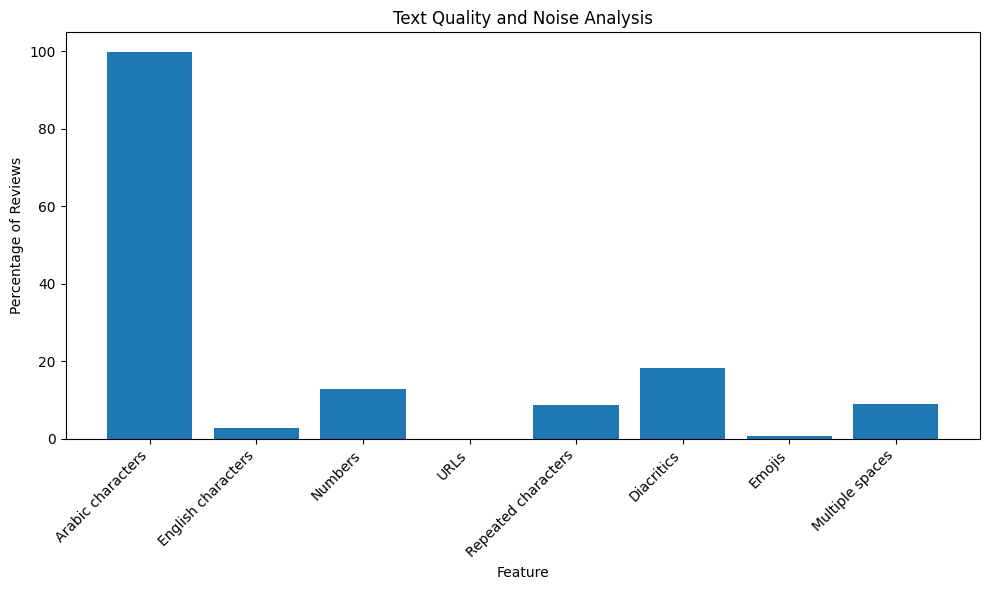

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    quality_df['Feature'],
    quality_df['Percentage']
)

plt.title('Text Quality and Noise Analysis')
plt.xlabel('Feature')
plt.ylabel('Percentage of Reviews')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Cleaning Functions

In [ ]:
print("50th percentile:", df['word_count'].quantile(0.50))
print("75th percentile:", df['word_count'].quantile(0.75))
print("90th percentile:", df['word_count'].quantile(0.90))
print("95th percentile:", df['word_count'].quantile(0.95))
print("99th percentile:", df['word_count'].quantile(0.99))

50th percentile: 17.0
75th percentile: 30.0
90th percentile: 50.0
95th percentile: 68.0
99th percentile: 121.0


In [ ]:
# Find potential length outliers
long_reviews = df.nlargest(
    20,
    'word_count'
)[['rating', 'review', 'sentiment', 'word_count']]

print(long_reviews.to_string(index=False))

 rating                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

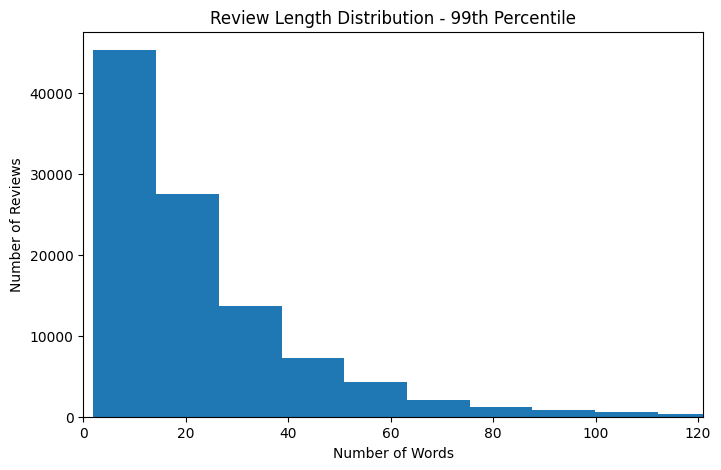

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['word_count'],
    bins=50
)

plt.xlim(0, df['word_count'].quantile(0.99))

plt.title('Review Length Distribution - 99th Percentile')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
# Compare review length between sentiments
length_stats = df.groupby('sentiment')['word_count'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

print(length_stats)

           count       mean  median        std  min  max
sentiment                                               
negative   52200  28.357203    20.0  28.413528    2  614
positive   51879  20.116752    14.0  19.421032    2  570


In [ ]:
rating_sentiment = pd.crosstab(
    df['rating'],
    df['sentiment']
)

print(rating_sentiment)

sentiment  negative  positive
rating                       
1             14071         0
2             38129         0
4                 0     26217
5                 0     25662


## Text Cleaning

In [ ]:
# make a copy

df['review_raw'] = df['review']

df[['review_raw', 'sentiment']].head()

,review_raw,sentiment
0,“ممتاز”. النظافة والطاقم متعاون.,negative
1,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...,positive
2,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...,positive
3,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...,negative
4,جيد. المكان جميل وهاديء. كل شي جيد ونظيف بس كا...,positive


In [ ]:
df['review_clean'] = df['review_raw'].copy()

In [ ]:
import re
import pandas as pd

### Apply Cleaning Versions

In [ ]:
# Remove URLs

def remove_urls(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    return text

In [ ]:
# Remove HTML entities
import html

def remove_html(text):
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    return text

In [ ]:
# Remove Arabic diacritics
def remove_diacritics(text):
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    return text

In [ ]:
# Normalize Arabic letters
def normalize_arabic(text):
    text = re.sub('[إأآا]', 'ا', text)
    text = re.sub('ى', 'ي', text)
    text = re.sub('ؤ', 'و', text)
    text = re.sub('ئ', 'ي', text)
    return text

In [ ]:
# # Normalize repeated characters
# def normalize_repeated_chars(text):
#     text = re.sub(r'(.)\1{2,}', r'\1', text)
#     return text

# We don't want:
# راااااائع → راع

In [ ]:
def normalize_repeated_chars(text):
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text

In [ ]:
# Remove punctuation
def remove_punctuation(text):
    text = re.sub(
        r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~،؛؟]',
        ' ',
        text
    )
    return text

In [ ]:
# Remove emojis

def remove_emojis(text):
    return re.sub(
        r'[\U0001F300-\U0001FAFF'
        r'\U00002700-\U000027BF'
        r'\U0001F1E6-\U0001F1FF]',
        ' ',
        text
    )

In [ ]:
# Remove English characters

def remove_english(text):
    return re.sub(
        r'[A-Za-z]+',
        ' ',
        text
    )

In [ ]:
# Remove numbers

def remove_numbers(text):
    return re.sub(
        r'[0-9٠-٩]+',
        ' ',
        text
    )

In [ ]:
# Normalize whitespace
def normalize_whitespace(text):
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [ ]:
# The main cleaning function
def clean_arabic_text(
    text,
    remove_emoji=False,
    arabic_only=False,
    remove_number=False,
    remove_stopwords=False,
    stemming=False
):

    text = str(text)

    # -------------------------
    # Basic cleaning
    # -------------------------

    # Remove URLs
    text = remove_urls(text)

    # Decode HTML entities and remove HTML tags
    text = remove_html(text)

    # Remove Arabic diacritics
    text = remove_diacritics(text)

    # Normalize Arabic letters
    text = normalize_arabic(text)

    # Normalize repeated characters
    text = normalize_repeated_chars(text)

    # Remove punctuation
    text = remove_punctuation(text)

    # -------------------------
    # Optional preprocessing
    # -------------------------

    if remove_emoji:
        text = remove_emojis(text)

    if arabic_only:
        text = remove_english(text)

    if remove_number:
        text = remove_numbers(text)

    # -------------------------
    # Whitespace
    # -------------------------

    text = normalize_whitespace(text)

    return text

In [ ]:
# Version 1 — Basic
df['review_v1_basic'] = df['review'].apply(
    lambda x: (
        normalize_whitespace(
            remove_html(
                remove_urls(
                    str(x)
                )
            )
        )
    )
)

In [ ]:
# Version 2 — Full cleaning
df['review_v2_clean'] = df['review'].apply(
    clean_arabic_text
)

In [ ]:
# Version 3 — Clean + remove emojis
df['review_v3_no_emoji'] = df['review'].apply(
    lambda x: clean_arabic_text(
        x,
        remove_emoji=True
    )
)

In [ ]:
# Version 4 — Arabic only
df['review_v4_arabic_only'] = df['review'].apply(
    lambda x: clean_arabic_text(
        x,
        remove_emoji=True,
        arabic_only=True
    )
)
# This version removes:

# English
# emojis
# punctuation
# URLs
# diacritics
# repeated characters

# but preserves numbers.

In [ ]:
# Version 5 — Remove numbers
df['review_v5_no_numbers'] = df['review'].apply(
    lambda x: clean_arabic_text(
        x,
        remove_number=True
    )
)

In [ ]:
# Version 6 — Stopword removal
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

arabic_stopwords = set(stopwords.words('arabic'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# preserve negation words.
negation_words = {
    'لا',
    'ليس',
    'ليست',
    'لم',
    'لن',
    'ما',
    'غير',
    'ولا',
    'بدون',
    'ليسوا',
    'لماذا'
}

arabic_stopwords_filtered = (
    arabic_stopwords - negation_words
)

In [ ]:
def remove_arabic_stopwords(text):
    words = text.split()

    words = [
        word
        for word in words
        if word not in arabic_stopwords_filtered
    ]

    return ' '.join(words)

In [ ]:
df['review_v6_stopwords'] = df['review'].apply(
    lambda x: remove_arabic_stopwords(
        clean_arabic_text(x)
    )
)

In [ ]:
# Version 7 — Stemming
from nltk.stem.isri import ISRIStemmer

stemmer = ISRIStemmer()

In [ ]:
def stem_arabic_text(text):
    words = text.split()

    stemmed_words = [
        stemmer.stem(word)
        for word in words
    ]

    return ' '.join(stemmed_words)

In [ ]:
df['review_v7_stemming'] = df['review'].apply(
    lambda x: stem_arabic_text(
        clean_arabic_text(x)
    )
)

In [ ]:
# Check all versions side-by-side
sample = df.sample(10, random_state=42)

for _, row in sample.iterrows():

    print("=" * 120)

    print("RAW:")
    print(row['review'])

    print("\nV1 BASIC:")
    print(row['review_v1_basic'])

    print("\nV2 CLEAN:")
    print(row['review_v2_clean'])

    print("\nV3 NO EMOJI:")
    print(row['review_v3_no_emoji'])

    print("\nV4 ARABIC ONLY:")
    print(row['review_v4_arabic_only'])

    print("\nV5 NO NUMBERS:")
    print(row['review_v5_no_numbers'])

    print("\nV6 STOPWORDS:")
    print(row['review_v6_stopwords'])

    print("\nV7 STEMMING:")
    print(row['review_v7_stemming'])

RAW:
“جيد”. قربه من القصباء. كل شيئ جميل

V1 BASIC:
“جيد”. قربه من القصباء. كل شيئ جميل

V2 CLEAN:
“جيد” قربه من القصباء كل شيي جميل

V3 NO EMOJI:
“جيد” قربه من القصباء كل شيي جميل

V4 ARABIC ONLY:
“جيد” قربه من القصباء كل شيي جميل

V5 NO NUMBERS:
“جيد” قربه من القصباء كل شيي جميل

V6 STOPWORDS:
“جيد” قربه القصباء شيي جميل

V7 STEMMING:
“جيد” قرب من قصباء كل شيي جمل
RAW:
ضعيف. . وجود حيوان البريعص في الغرفة

V1 BASIC:
ضعيف. . وجود حيوان البريعص في الغرفة

V2 CLEAN:
ضعيف وجود حيوان البريعص في الغرفة

V3 NO EMOJI:
ضعيف وجود حيوان البريعص في الغرفة

V4 ARABIC ONLY:
ضعيف وجود حيوان البريعص في الغرفة

V5 NO NUMBERS:
ضعيف وجود حيوان البريعص في الغرفة

V6 STOPWORDS:
ضعيف وجود حيوان البريعص الغرفة

V7 STEMMING:
ضعف وجد حيو ريعص في غرف
RAW:
“رحلة عمل وراحة”. كل الشكر والتقدير للمدير العام السيد رضا مختار على حسن رعايته ورقي تعامله 👍🌹وكذلك الطاقم المميز له وهم السكرتيرة الراقية تانيا ومستر بالا شكراً لكم من القلب 🌹🌹🌹. التأخير بإستلام الجناح الخاص بنا لكن بفضل حسن ادارة السيد رضا مختار تم عمل الل

In [ ]:
# Check the vocabulary size of every version
versions = [
    'review_v1_basic',
    'review_v2_clean',
    'review_v3_no_emoji',
    'review_v4_arabic_only',
    'review_v5_no_numbers',
    'review_v6_stopwords',
    'review_v7_stemming'
]

for col in versions:

    vocabulary = set(
        ' '.join(
            df[col].astype(str)
        ).split()
    )

    print(
        f"{col}: {len(vocabulary):,} unique words"
    )

review_v1_basic: 196,833 unique words
review_v2_clean: 145,625 unique words
review_v3_no_emoji: 145,129 unique words
review_v4_arabic_only: 140,519 unique words
review_v5_no_numbers: 140,744 unique words
review_v6_stopwords: 145,304 unique words
review_v7_stemming: 64,700 unique words


In [ ]:
# Check average review length for every version
for col in versions:

    word_counts = df[col].str.split().str.len()

    print(
        f"{col}: "
        f"mean={word_counts.mean():.2f}, "
        f"median={word_counts.median():.2f}"
    )

review_v1_basic: mean=24.25, median=17.00
review_v2_clean: mean=23.81, median=16.00
review_v3_no_emoji: mean=23.81, median=16.00
review_v4_arabic_only: mean=23.65, median=16.00
review_v5_no_numbers: mean=23.61, median=16.00
review_v6_stopwords: mean=21.05, median=15.00
review_v7_stemming: mean=23.81, median=16.00


In [ ]:
# Check for empty reviews
for col in versions:

    empty_count = (
        df[col].str.strip() == ''
    ).sum()

    print(
        f"{col}: {empty_count:,} empty reviews"
    )

review_v1_basic: 0 empty reviews
review_v2_clean: 0 empty reviews
review_v3_no_emoji: 0 empty reviews
review_v4_arabic_only: 0 empty reviews
review_v5_no_numbers: 0 empty reviews
review_v6_stopwords: 0 empty reviews
review_v7_stemming: 0 empty reviews


## Feature Engineering: TF-IDF

In [ ]:
versions

['review_v1_basic',
 'review_v2_clean',
 'review_v3_no_emoji',
 'review_v4_arabic_only',
 'review_v5_no_numbers',
 'review_v6_stopwords',
 'review_v7_stemming']

In [ ]:
df[versions]

,review_v1_basic,review_v2_clean,review_v3_no_emoji,review_v4_arabic_only,review_v5_no_numbers,review_v6_stopwords,review_v7_stemming
0,“ممتاز”. النظافة والطاقم متعاون.,“ممتاز” النظافة والطاقم متعاون,“ممتاز” النظافة والطاقم متعاون,“ممتاز” النظافة والطاقم متعاون,“ممتاز” النظافة والطاقم متعاون,“ممتاز” النظافة والطاقم متعاون,“ممتاز” نظف طقم تعا
1,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...,استثنايي سهولة انهاء المعاملة في الاستقبال لاشيي,استثنايي سهولة انهاء المعاملة في الاستقبال لاشيي,استثنايي سهولة انهاء المعاملة في الاستقبال لاشيي,استثنايي سهولة انهاء المعاملة في الاستقبال لاشيي,استثنايي سهولة انهاء المعاملة الاستقبال لاشيي,استثنايي سهل هاء عمل في قبل لشي
2,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...,استثنايي انصح باختيار الاسويت و بالاخص غرفه رق...,استثنايي انصح باختيار الاسويت و بالاخص غرفه رق...,استثنايي انصح باختيار الاسويت و بالاخص غرفه رق...,استثنايي انصح باختيار الاسويت و بالاخص غرفه رق...,استثنايي انصح باختيار الاسويت بالاخص غرفه رقم ...,استثنايي نصح خير اسي و اخص غرف رقم 801 نوع ارض
3,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...,“استغرب تقييم الفندق كخمس نجوم” لا شي يستحق 2 ...,“استغرب تقييم الفندق كخمس نجوم” لا شي يستحق 2 ...,“استغرب تقييم الفندق كخمس نجوم” لا شي يستحق 2 ...,“استغرب تقييم الفندق كخمس نجوم” لا شي يستحق نجمه,“استغرب تقييم الفندق كخمس نجوم” لا شي يستحق 2 ...,“استغرب قيم ندق كخمس جوم” لا شي سحق 2 نجم
4,جيد. المكان جميل وهاديء. كل شي جيد ونظيف بس كا...,جيد المكان جميل وهاديء كل شي جيد ونظيف بس كان ...,جيد المكان جميل وهاديء كل شي جيد ونظيف بس كان ...,جيد المكان جميل وهاديء كل شي جيد ونظيف بس كان ...,جيد المكان جميل وهاديء كل شي جيد ونظيف بس كان ...,جيد المكان جميل وهاديء شي جيد ونظيف حوض السباح...,جيد كان جمل هاديء كل شي جيد نظف بس كان حوض سبح...
...,...,...,...,...,...,...,...
105693,“فند”. لا شئ عجبني. طقم العمل سيئ جدالا يوجد ب...,“فند” لا شي عجبني طقم العمل سيي جدالا يوجد بال...,“فند” لا شي عجبني طقم العمل سيي جدالا يوجد بال...,“فند” لا شي عجبني طقم العمل سيي جدالا يوجد بال...,“فند” لا شي عجبني طقم العمل سيي جدالا يوجد بال...,“فند” لا شي عجبني طقم العمل سيي جدالا يوجد بال...,“فند” لا شي عجب طقم عمل سيي جدل وجد ندق اي خدم...
105694,“سيئ”. قربه من المسجد النبوي الشريف. استخدام م...,“سيي” قربه من المسجد النبوي الشريف استخدام موظ...,“سيي” قربه من المسجد النبوي الشريف استخدام موظ...,“سيي” قربه من المسجد النبوي الشريف استخدام موظ...,“سيي” قربه من المسجد النبوي الشريف استخدام موظ...,“سيي” قربه المسجد النبوي الشريف استخدام موظف ا...,“سيي” قرب من سجد نبي شرف خدم وظف قبل وقف خصص ع...
105695,“اسوأ إقامة في الرحلة !”. القرب من الحرم. كل ش...,“اسوا اقامة في الرحلة ” القرب من الحرم كل شيء ...,“اسوا اقامة في الرحلة ” القرب من الحرم كل شيء ...,“اسوا اقامة في الرحلة ” القرب من الحرم كل شيء ...,“اسوا اقامة في الرحلة ” القرب من الحرم كل شيء ...,“اسوا اقامة الرحلة ” القرب الحرم شيء ازعاج عدم...,“اس قمة في رحل ” قرب من حرم كل شيء زعج عدم جوب...
105696,“دون المستوى”. قربه من الحرم. كل شيء,“دون المستوي” قربه من الحرم كل شيء,“دون المستوي” قربه من الحرم كل شيء,“دون المستوي” قربه من الحرم كل شيء,“دون المستوي” قربه من الحرم كل شيء,“دون المستوي” قربه الحرم شيء,“دن وي” قرب من حرم كل شيء


In [ ]:
# Separate X and y
X = df[versions]
y = df['sentiment']

In [ ]:
# Encode the sentiment
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['negative' 'positive']


In [ ]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
import numpy as np

print("Training set:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTest set:")
print(pd.Series(y_test).value_counts(normalize=True))

Training set:
0    0.501543
1    0.498457
Name: proportion, dtype: float64

Test set:
0    0.501537
1    0.498463
Name: proportion, dtype: float64


In [ ]:
# TF-IDF (Term Frequency – Inverse Document Frequency)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(
    X_train['review_v2_clean']
)

X_test_tfidf = tfidf.transform(
    X_test['review_v2_clean']
)

In [ ]:
tfidf.fit_transform(
    df['review_v2_clean']
)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2474681 stored elements and shape (104079, 10000)>

In [ ]:
# Check the dimensions
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (83263, 10000)
Testing shape: (20816, 10000)


In [ ]:
# Inspect the vocabulary
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 10000

First 50 features:
['00' '10' '10 دقايق' '100' '100 درهم' '100 ريال' '11' '12' '12 ظهرا' '14'
 '15' '15 دقيقة' '150' '20' '200' '200 ريال' '24' '24 ساعة' '24 ساعه' '25'
 '250' '30' '300' '40' '400' '45' '50' '50 ريال' '500' '500 درهم'
 '500 ريال' '5نجوم' '60' '600' 'all' 'and' 'and the' 'are' 'as' 'at' 'bad'
 'be' 'bed' 'booking' 'booking com' 'breakfast' 'but' 'check' 'check in'
 'check out']


In [ ]:
tfidf_data = {}

for version in versions:

    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    X_train_version = vectorizer.fit_transform(
        X_train[version]
    )

    X_test_version = vectorizer.transform(
        X_test[version]
    )

    tfidf_data[version] = {
        'vectorizer': vectorizer,
        'X_train': X_train_version,
        'X_test': X_test_version
    }

    print(
        version,
        "→",
        X_train_version.shape,
        X_test_version.shape
    )

review_v1_basic → (83263, 10000) (20816, 10000)
review_v2_clean → (83263, 10000) (20816, 10000)
review_v3_no_emoji → (83263, 10000) (20816, 10000)
review_v4_arabic_only → (83263, 10000) (20816, 10000)
review_v5_no_numbers → (83263, 10000) (20816, 10000)
review_v6_stopwords → (83263, 10000) (20816, 10000)
review_v7_stemming → (83263, 10000) (20816, 10000)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
models = {

    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Naive Bayes': MultinomialNB(),

    'Complement NB': ComplementNB(),

    'Linear SVM': LinearSVC(
        random_state=42
    ),

    'SGD Classifier': SGDClassifier(
        loss='hinge',
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    roc_auc = roc_auc_score(y_test, y_score)

    return {
        'model': model,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

In [ ]:
print(df.columns.tolist())

['rating', 'review', 'sentiment', 'review_length', 'word_count', 'char_count_no_spaces', 'review_raw', 'review_clean', 'review_v1_basic', 'review_v2_clean', 'review_v3_no_emoji', 'review_v4_arabic_only', 'review_v5_no_numbers', 'review_v6_stopwords', 'review_v7_stemming']


In [ ]:
versions = [
    'review_v1_basic',
    'review_v2_clean',
    'review_v3_no_emoji',
    'review_v4_arabic_only',
    'review_v5_no_numbers',
    'review_v6_stopwords',
    'review_v7_stemming'
]

In [ ]:
print("X_train columns:")
print(X_train.columns.tolist())

print("\nX_test columns:")
print(X_test.columns.tolist())

X_train columns:
['review_v1_basic', 'review_v2_clean', 'review_v3_no_emoji', 'review_v4_arabic_only', 'review_v5_no_numbers', 'review_v6_stopwords', 'review_v7_stemming']

X_test columns:
['review_v1_basic', 'review_v2_clean', 'review_v3_no_emoji', 'review_v4_arabic_only', 'review_v5_no_numbers', 'review_v6_stopwords', 'review_v7_stemming']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_data = {}

for version in versions:

    print("=" * 70)
    print(f"TF-IDF: {version}")

    vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    X_train_version = vectorizer.fit_transform(
        X_train[version]
    )

    X_test_version = vectorizer.transform(
        X_test[version]
    )

    tfidf_data[version] = {
        'vectorizer': vectorizer,
        'X_train': X_train_version,
        'X_test': X_test_version
    }

    print("Train:", X_train_version.shape)
    print("Test :", X_test_version.shape)

TF-IDF: review_v1_basic
Train: (83263, 10000)
Test : (20816, 10000)
TF-IDF: review_v2_clean
Train: (83263, 10000)
Test : (20816, 10000)
TF-IDF: review_v3_no_emoji
Train: (83263, 10000)
Test : (20816, 10000)
TF-IDF: review_v4_arabic_only
Train: (83263, 10000)
Test : (20816, 10000)
TF-IDF: review_v5_no_numbers
Train: (83263, 10000)
Test : (20816, 10000)
TF-IDF: review_v6_stopwords
Train: (83263, 10000)
Test : (20816, 10000)
TF-IDF: review_v7_stemming
Train: (83263, 10000)
Test : (20816, 10000)


In [ ]:
print("\nTF-IDF versions:")
print(list(tfidf_data.keys()))


TF-IDF versions:
['review_v1_basic', 'review_v2_clean', 'review_v3_no_emoji', 'review_v4_arabic_only', 'review_v5_no_numbers', 'review_v6_stopwords', 'review_v7_stemming']


In [ ]:
all_results = []
trained_models = {}

for version in versions:

    print("\n" + "=" * 70)
    print(f"PREPROCESSING VERSION: {version}")
    print("=" * 70)

    X_train_version = tfidf_data[version]['X_train']
    X_test_version = tfidf_data[version]['X_test']

    trained_models[version] = {}

    for model_name, model in models.items():

        print(f"Training {model_name}...")

        result = evaluate_model(
            model,
            X_train_version,
            X_test_version,
            y_train,
            y_test
        )

        # Store model
        trained_models[version][model_name] = result

        # Store metrics
        all_results.append({
            'Preprocessing': version,
            'Model': model_name,
            'Accuracy': result['accuracy'],
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1': result['f1'],
            'ROC-AUC': result['roc_auc']
        })

        print(
            f"F1: {result['f1']:.4f} | "
            f"ROC-AUC: {result['roc_auc']:.4f}"
        )


PREPROCESSING VERSION: review_v1_basic
Training Logistic Regression...
F1: 0.9380 | ROC-AUC: 0.9791
Training Naive Bayes...
F1: 0.9068 | ROC-AUC: 0.9665
Training Complement NB...
F1: 0.9073 | ROC-AUC: 0.9665
Training Linear SVM...
F1: 0.9315 | ROC-AUC: 0.9773
Training SGD Classifier...
F1: 0.9365 | ROC-AUC: 0.9777
Training Decision Tree...
F1: 0.8714 | ROC-AUC: 0.8723
Training Random Forest...
F1: 0.9202 | ROC-AUC: 0.9715

PREPROCESSING VERSION: review_v2_clean
Training Logistic Regression...
F1: 0.9390 | ROC-AUC: 0.9795
Training Naive Bayes...
F1: 0.9088 | ROC-AUC: 0.9670
Training Complement NB...
F1: 0.9090 | ROC-AUC: 0.9670
Training Linear SVM...
F1: 0.9305 | ROC-AUC: 0.9777
Training SGD Classifier...
F1: 0.9371 | ROC-AUC: 0.9782
Training Decision Tree...
F1: 0.8728 | ROC-AUC: 0.8736
Training Random Forest...
F1: 0.9220 | ROC-AUC: 0.9723

PREPROCESSING VERSION: review_v3_no_emoji
Training Logistic Regression...
F1: 0.9390 | ROC-AUC: 0.9795
Training Naive Bayes...
F1: 0.9088 | ROC-A

### Best Classical Model Analysis

## Classical Machine Learning Models

### Model Training and Evaluation

In [ ]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by='F1',
    ascending=False
).reset_index(drop=True)

In [ ]:
display(results_df)

,Preprocessing,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,review_v6_stopwords,Logistic Regression,0.939566,0.935102,0.944295,0.939676,0.979755
1,review_v4_arabic_only,Logistic Regression,0.938845,0.933517,0.944584,0.939018,0.979359
2,review_v2_clean,Logistic Regression,0.938797,0.933511,0.944487,0.938967,0.979469
3,review_v3_no_emoji,Logistic Regression,0.938797,0.933511,0.944487,0.938967,0.979469
4,review_v5_no_numbers,Logistic Regression,0.938269,0.933524,0.943331,0.938402,0.979448
5,review_v1_basic,Logistic Regression,0.937836,0.932394,0.943716,0.938021,0.979064
6,review_v6_stopwords,SGD Classifier,0.937212,0.928875,0.946511,0.937610,0.978562
7,review_v4_arabic_only,SGD Classifier,0.936779,0.927843,0.946800,0.937226,0.978050
8,review_v2_clean,SGD Classifier,0.936683,0.928558,0.945740,0.937070,0.978210
9,review_v3_no_emoji,SGD Classifier,0.936683,0.928558,0.945740,0.937070,0.978210


In [ ]:
print("Top 10 experiments based on F1:")
display(
    results_df.head(10)
)

Top 10 experiments based on F1:


,Preprocessing,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,review_v6_stopwords,Logistic Regression,0.939566,0.935102,0.944295,0.939676,0.979755
1,review_v4_arabic_only,Logistic Regression,0.938845,0.933517,0.944584,0.939018,0.979359
2,review_v2_clean,Logistic Regression,0.938797,0.933511,0.944487,0.938967,0.979469
3,review_v3_no_emoji,Logistic Regression,0.938797,0.933511,0.944487,0.938967,0.979469
4,review_v5_no_numbers,Logistic Regression,0.938269,0.933524,0.943331,0.938402,0.979448
5,review_v1_basic,Logistic Regression,0.937836,0.932394,0.943716,0.938021,0.979064
6,review_v6_stopwords,SGD Classifier,0.937212,0.928875,0.946511,0.937610,0.978562
7,review_v4_arabic_only,SGD Classifier,0.936779,0.927843,0.946800,0.937226,0.978050
8,review_v2_clean,SGD Classifier,0.936683,0.928558,0.945740,0.937070,0.978210
9,review_v3_no_emoji,SGD Classifier,0.936683,0.928558,0.945740,0.937070,0.978210


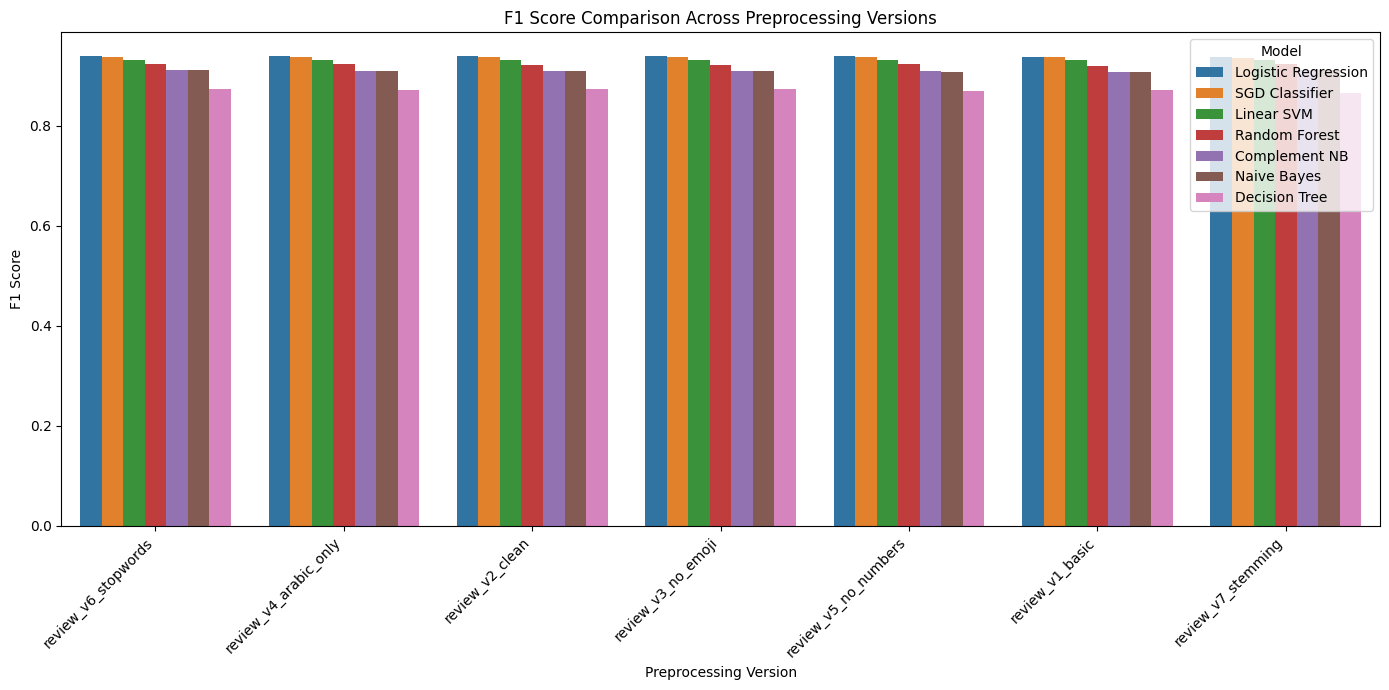

In [ ]:
# Visualize F1 score
plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x='Preprocessing',
    y='F1',
    hue='Model'
)

plt.title(
    'F1 Score Comparison Across Preprocessing Versions'
)

plt.xlabel('Preprocessing Version')
plt.ylabel('F1 Score')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

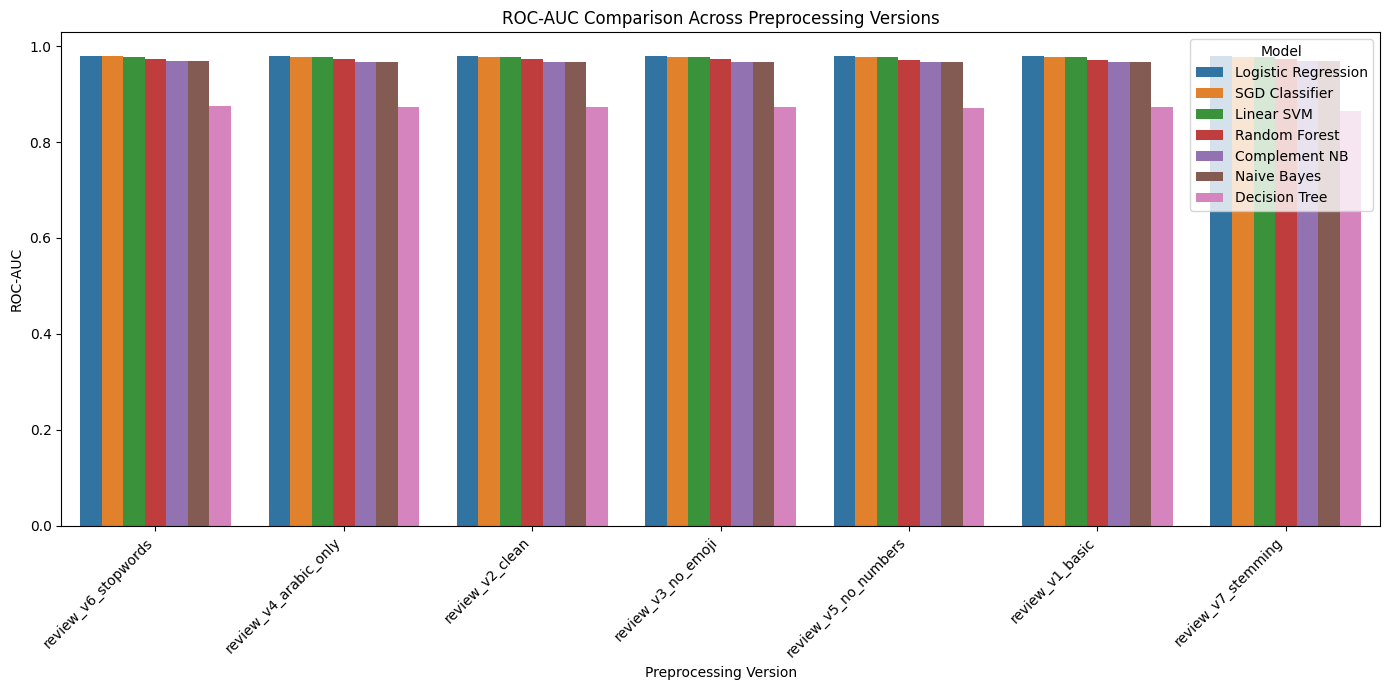

In [ ]:
# Visualize ROC-AUC
plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x='Preprocessing',
    y='ROC-AUC',
    hue='Model'
)

plt.title(
    'ROC-AUC Comparison Across Preprocessing Versions'
)

plt.xlabel('Preprocessing Version')
plt.ylabel('ROC-AUC')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

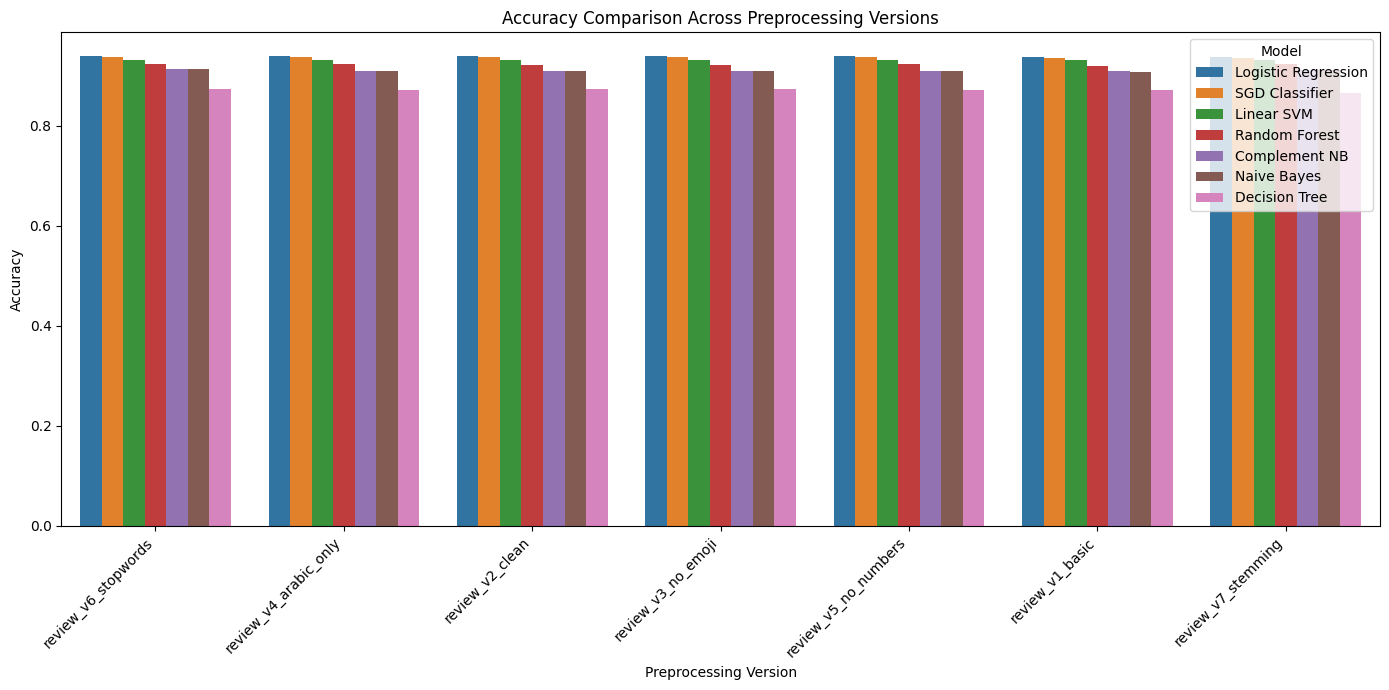

In [ ]:
# Visualize Accuracy
plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x='Preprocessing',
    y='Accuracy',
    hue='Model'
)

plt.title(
    'Accuracy Comparison Across Preprocessing Versions'
)

plt.xlabel('Preprocessing Version')
plt.ylabel('Accuracy')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

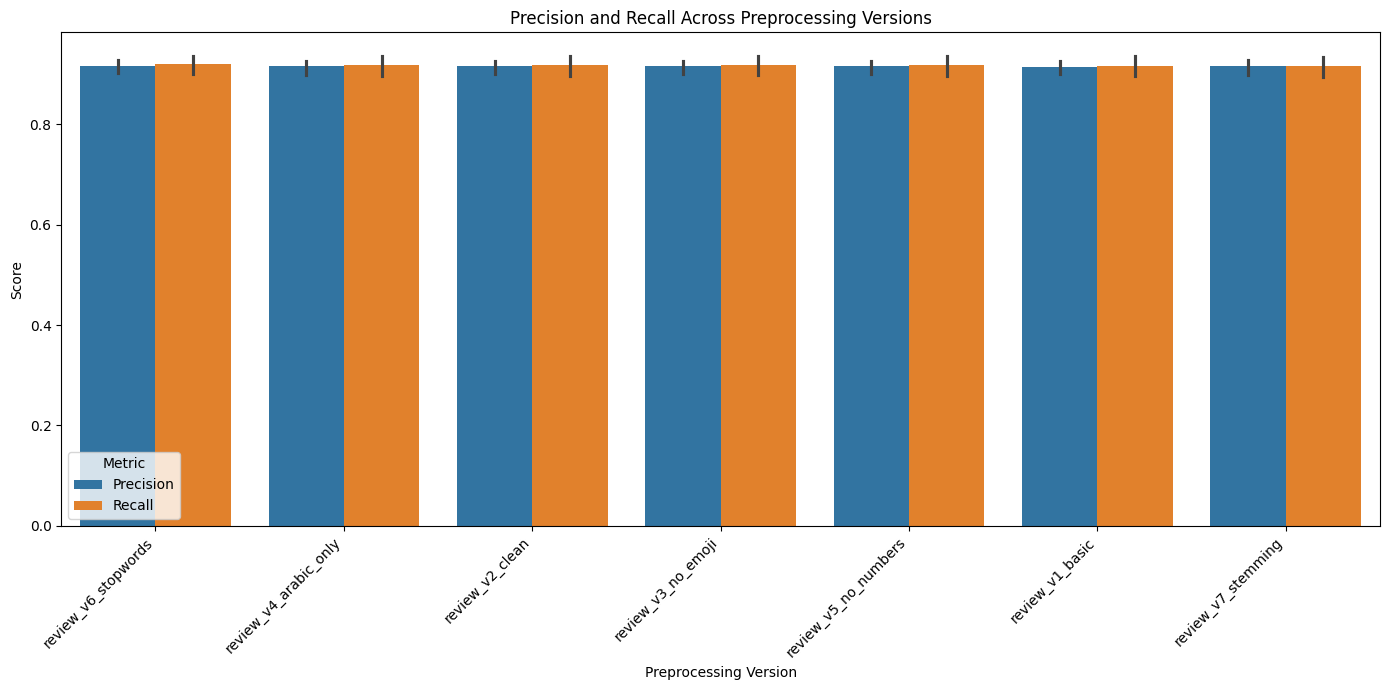

In [ ]:
# Visualize Precision and Recall
precision_recall_df = results_df.melt(
    id_vars=['Preprocessing', 'Model'],
    value_vars=['Precision', 'Recall'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=precision_recall_df,
    x='Preprocessing',
    y='Score',
    hue='Metric'
)

plt.title(
    'Precision and Recall Across Preprocessing Versions'
)

plt.xlabel('Preprocessing Version')
plt.ylabel('Score')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Best preprocessing:
review_v6_stopwords

Best model:
Logistic Regression

F1:
0.9397

ROC-AUC:
0.9798


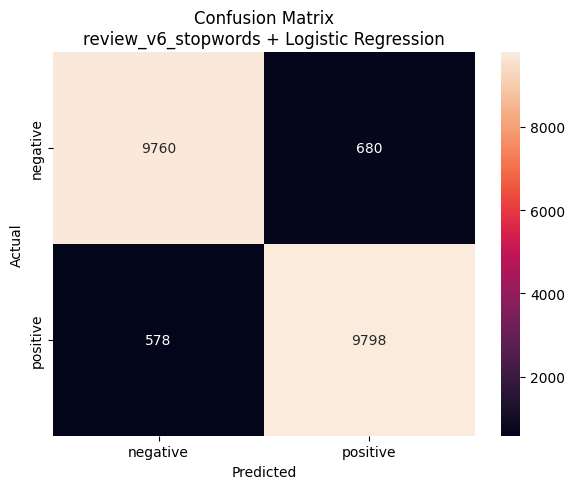

In [ ]:
# Confusion matrix for the best model

best_row = results_df.iloc[0]

print("Best preprocessing:")
print(best_row['Preprocessing'])

print("\nBest model:")
print(best_row['Model'])

print("\nF1:")
print(f"{best_row['F1']:.4f}")

print("\nROC-AUC:")
print(f"{best_row['ROC-AUC']:.4f}")

best_version = best_row['Preprocessing']
best_model_name = best_row['Model']

best_result = trained_models[
    best_version
][
    best_model_name
]

y_pred_best = best_result['y_pred']

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    f'Confusion Matrix\n{best_version} + {best_model_name}'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

### Data Preparation for LSTM

## LSTM Model

In [ ]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
print(tf.__version__)

2.20.0


In [ ]:
lstm_text_column = 'review_v6_stopwords'

X_train_lstm = X_train[lstm_text_column].astype(str)
X_test_lstm = X_test[lstm_text_column].astype(str)

### LSTM Model Architecture

In [ ]:
MAX_VOCAB_SIZE = 30000

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(X_train_lstm)

In [ ]:
X_train_sequences = tokenizer.texts_to_sequences(
    X_train_lstm
)

X_test_sequences = tokenizer.texts_to_sequences(
    X_test_lstm
)

In [ ]:
# Analyze sequence lengths
train_lengths = [
    len(seq)
    for seq in X_train_sequences
]

print("Minimum:", np.min(train_lengths))
print("Maximum:", np.max(train_lengths))
print("Mean:", np.mean(train_lengths))
print("Median:", np.median(train_lengths))

print("90th percentile:",
      np.percentile(train_lengths, 90))

print("95th percentile:",
      np.percentile(train_lengths, 95))

print("99th percentile:",
      np.percentile(train_lengths, 99))

Minimum: 1
Maximum: 530
Mean: 21.01042479852996
Median: 15.0
90th percentile: 43.0
95th percentile: 58.0
99th percentile: 102.0


In [ ]:
MAX_LEN = 60

In [ ]:
X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [ ]:
print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (83263, 60)
Testing shape: (20816, 60)


In [ ]:
# Build the LSTM model
VOCAB_SIZE = min(
    MAX_VOCAB_SIZE,
    len(tokenizer.word_index) + 1
)

EMBEDDING_DIM = 128

lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)

VOCAB_SIZE = min(
    MAX_VOCAB_SIZE,
    len(tokenizer.word_index) + 1
)

EMBEDDING_DIM = 128

lstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,979,905 (15.18 MB)

 Trainable params: 3,979,905 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

### LSTM Model Training and Evaluation

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy'
    ]
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 213s 358ms/step - accuracy: 0.7860 - loss: 0.4595 - val_accuracy: 0.7782 - val_loss: 0.4534
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 209s 357ms/step - accuracy: 0.8138 - loss: 0.4462 - val_accuracy: 0.8813 - val_loss: 0.3613
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 210s 359ms/step - accuracy: 0.8600 - loss: 0.3919 - val_accuracy: 0.8693 - val_loss: 0.3591
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 261s 357ms/step - accuracy: 0.8929 - loss: 0.3246 - val_accuracy: 0.9038 - val_loss: 0.2922
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 215s 367ms/step - accuracy: 0.9256 - loss: 0.2227 - val_accuracy: 0.9346 - val_loss: 0.1874


In [ ]:
y_prob_lstm = lstm_model.predict(
    X_test_pad
).ravel()

y_pred_lstm = (
    y_prob_lstm >= 0.5
).astype(int)

651/651 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step


In [ ]:
accuracy_lstm = accuracy_score(
    y_test,
    y_pred_lstm
)

precision_lstm = precision_score(
    y_test,
    y_pred_lstm
)

recall_lstm = recall_score(
    y_test,
    y_pred_lstm
)

f1_lstm = f1_score(
    y_test,
    y_pred_lstm
)

roc_auc_lstm = roc_auc_score(
    y_test,
    y_prob_lstm
)

print(f"Accuracy : {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall   : {recall_lstm:.4f}")
print(f"F1       : {f1_lstm:.4f}")
print(f"ROC-AUC  : {roc_auc_lstm:.4f}")

Accuracy : 0.9324
Precision: 0.9195
Recall   : 0.9472
F1       : 0.9332
ROC-AUC  : 0.9789


In [ ]:
print(classification_report(
        y_test,
        y_pred_lstm,
        target_names=label_encoder.classes_
    ))

              precision    recall  f1-score   support

    negative       0.95      0.92      0.93     10440
    positive       0.92      0.95      0.93     10376

    accuracy                           0.93     20816
   macro avg       0.93      0.93      0.93     20816
weighted avg       0.93      0.93      0.93     20816



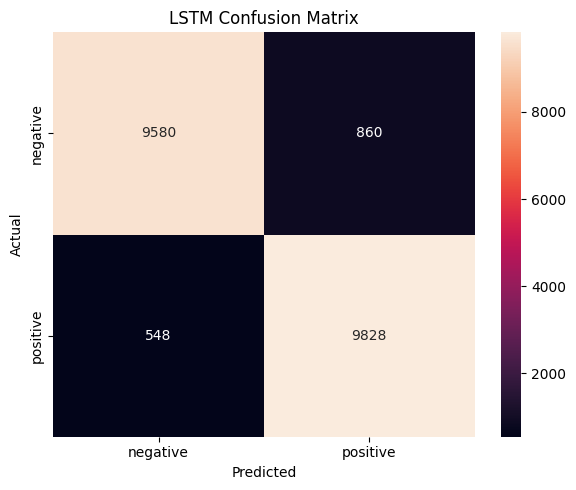

In [ ]:
cm_lstm = confusion_matrix(
    y_test,
    y_pred_lstm
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('LSTM Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

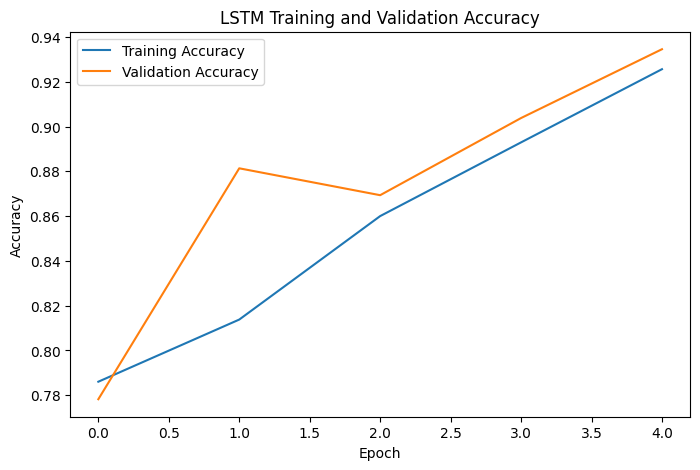

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

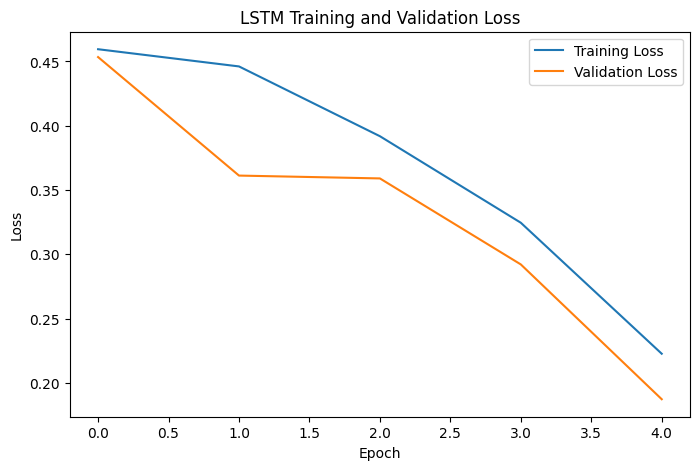

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Model Comparison

In [ ]:
lstm_result = pd.DataFrame([{
    'Preprocessing': 'review_v6_stopwords',
    'Model': 'LSTM',
    'Accuracy': accuracy_lstm,
    'Precision': precision_lstm,
    'Recall': recall_lstm,
    'F1': f1_lstm,
    'ROC-AUC': roc_auc_lstm
}])

display(lstm_result)

,Preprocessing,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,review_v6_stopwords,LSTM,0.93236,0.919536,0.947186,0.933156,0.978885


In [ ]:
best_classical = results_df.head(1)

comparison = pd.concat(
    [
        best_classical,
        lstm_result
    ],
    ignore_index=True
)

display(comparison)

,Preprocessing,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,review_v6_stopwords,Logistic Regression,0.939566,0.935102,0.944295,0.939676,0.979755
1,review_v6_stopwords,LSTM,0.932360,0.919536,0.947186,0.933156,0.978885
